<a href="https://colab.research.google.com/github/Y4S1-DL-Project/DeepLearning_Project/blob/feature%2Fbuddhima/InceptionV3_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 0.1 Check TF and GPU
import tensorflow as tf
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# 1. Imports and global config
import os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras import regularizers

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. GLOBAL SETTINGS
TRAIN_DIR = "/content/drive/MyDrive/Data set/Flowers Train"
TEST_DIR = "/content/drive/MyDrive/Data set/Flowers Test"

# InceptionV3 prefers 299x299 input
IMG_SIZE = (299, 299)
BATCH_SIZE = 32    #how many images will be processed by the model at once
SEED = 42          #ensures same random results for debugging and testing.

In [ ]:
# # Human-readable label mapping
# 2. Map folder codes to full species names (from your list)
orchid_label_map = {
    "n0000": "Anoectochilus burmanicus rolfe",
    "n0001": "Bulbophyllum auricomum lindl",
    "n0002": "Bulbophyllum dayanum rchb",
    "n0003": "Bulbophyllum lasiochilum par. & rchb",
    "n0004": "Bulbophyllum limbatum",
    "n0005": "Bulbophyllum longissimum (ridl.) ridl",
    "n0006": "Bulbophyllum medusae (lindl.) rchb",
    "n0007": "Bulbophyllum patens king ex hk.f.",
    "n0008": "Bulbophyllum rufuslabram",
    "n0009": "Bulbophyllum siamensis rchb",
    "n0010": "Calenthe rubens",
    "n0011": "Chiloschista parishii seidenf.",
    "n0012": "Chiloschista viridiflora seidenf.",
    "n0013": "Cymbidium aloifolium (l.) sw.",
    "n0014": "Dendrobium chrysotoxum lindl",
    "n0015": "Dendrobium farmeri paxt.",
    "n0016": "Dendrobium fimbriatum hook",
    "n0017": "Dendrobium lindleyi steud",
    "n0018": "Dendrobium pulchellum roxb",
    "n0019": "Dendrobium pulchellum",
    "n0020": "Dendrobium secundum bl-lindl",
    "n0021": "Dendrobium senile par. & rchb.f.",
    "n0022": "Dendrobium signatum rchb. f",
    "n0023": "Dendrobium thyrsiflorum rchb. f.",
    "n0024": "Dendrobium tortile lindl",
    "n0025": "Dendrobium tortile",
    "n0026": "Hygrochillus parishii var. marrioftiana (rchb.f.)",
    "n0027": "Paphiopedilum bellatulum",
    "n0028": "Paphiopedilum callosum",
    "n0029": "Paphiopedilum charlesworthii",
    "n0030": "Paphiopedilum concolor",
    "n0031": "Paphiopedilum exul",
    "n0032": "Paphiopedilum godefroyae",
    "n0033": "Paphiopedilum gratrixianum",
    "n0034": "Paphiopedilum henryanum",
    "n0035": "Paphiopedilum intanon-villosum",
    "n0036": "Paphiopedilum niveum (rchb.f.) stein",
    "n0037": "Paphiopedilum parishii",
    "n0038": "Paphiopedilum spicerianum",
    "n0039": "Paphiopedilum sukhakulii",
    "n0040": "Pelatantheria bicuspidata (rolfe ex downie) tang & wang",
    "n0041": "Pelatantheria insectiflora (rchb.f.) ridl.",
    "n0042": "Phaius tankervilleae (banks ex i' heritier) blume",
    "n0043": "Phalaenopsis cornucervi (breda) bl. & rchb.f.",
    "n0044": "Rhynchostylis gigantea (lindl.) ridl.",
    "n0045": "Trichoglottis orchideae (koern) garay.",
    "n0046": "Bulbophyllum auratum Lindl.",
    "n0047": "Bulbophyllum morphologorum F.Kranzl.",
    "n0048": "Dendrobium cumulatum Lindl.",
    "n0049": "Maxiralia tenui folia",
    "n0050": "Paphiopedilum vejvarutianum O. Gruss & Roellke",
    "n0051": "Oncidium goldiana"
}


In [ ]:
# Map index to readable class names
orchid_label_map = {}

In [ ]:
# 3. DATA GENERATORS -

# ----- Training Data Generator -----
# Applies data augmentation to increase dataset diversity
train_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ----- Testing Data Generator -----
# Only preprocessing; no augmentation applied to test data
test_aug = ImageDataGenerator(preprocessing_function=preprocess_input)

# ----- Load Training Images -----
train_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE, # Resize images
    batch_size=BATCH_SIZE, # Batch size same as training
    class_mode='categorical', # Multi-class output
    shuffle=True,
    seed=SEED
)

# ----- Load Testing Images -----
test_gen = test_aug.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Class names
index_to_folder = {v:k for k,v in train_gen.class_indices.items()}

# Map folder names
class_names = [orchid_label_map.get(index_to_folder[i], index_to_folder[i]) for i in range(len(index_to_folder))]

print(f"Train samples: {train_gen.samples} | Test samples: {test_gen.samples}")

Found 2820 images belonging to 52 classes.
Found 739 images belonging to 52 classes.
Train samples: 2820 | Test samples: 739


In [ ]:
# 4. CLASS WEIGHT COMPUTATION - Compute class weights to help with imbalance

y_train = train_gen.classes

# Find all unique class IDs
unique = np.unique(y_train)
# Compute class weights to handle class imbalance
class_weights_values = compute_class_weight(class_weight='balanced', classes=unique, y=y_train)
class_weight = {i:w for i,w in enumerate(class_weights_values)}

print("Class weights:", class_weight)

Class weights: {0: np.float64(1.1298076923076923), 1: np.float64(1.1298076923076923), 2: np.float64(2.465034965034965), 3: np.float64(1.1067503924646782), 4: np.float64(3.0128205128205128), 5: np.float64(1.870026525198939), 6: np.float64(2.3578595317725752), 7: np.float64(3.389423076923077), 8: np.float64(2.169230769230769), 9: np.float64(1.2611806797853309), 10: np.float64(2.854251012145749), 11: np.float64(0.6162587412587412), 12: np.float64(1.1067503924646782), 13: np.float64(0.7747252747252747), 14: np.float64(1.0846153846153845), 15: np.float64(1.2611806797853309), 16: np.float64(0.8216783216783217), 17: np.float64(0.3766025641025641), 18: np.float64(0.5214497041420119), 19: np.float64(1.0633484162895928), 20: np.float64(0.5894648829431438), 21: np.float64(1.9368131868131868), 22: np.float64(2.0857988165680474), 23: np.float64(2.465034965034965), 24: np.float64(0.32867132867132864), 25: np.float64(2.854251012145749), 26: np.float64(1.749379652605459), 27: np.float64(0.602564102564

In [ ]:
# 5. BUILD INCEPTIONV3 TRANSFER LEARNING MODEL
def build_inception_transfer(num_classes, input_shape=(299,299,3), dropout_rate=0.5):
# dropout_rate = 0.5 - 50% of neurons are ignored in each training step.

    # Load InceptionV3 base model with pretrained ImageNet weights
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    # Add custom classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Create full model combining base + head
    model = models.Model(inputs=base_model.input, outputs=outputs)
    return base_model, model

# Build the model
base_model, model = build_inception_transfer(len(class_names), input_shape=(IMG_SIZE[0], IMG_SIZE[1],3))
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 22,880,596 (87.28 MB)

 Trainable params: 1,076,788 (4.11 MB)

 Non-trainable params: 21,803,808 (83.17 MB)

In [ ]:
# 6. COMPILE MODEL & SET CALLBACKS

# Set initial learning rate
initial_lr = 1e-3

# Compile model
model.compile(
    optimizer=optimizers.Adam(learning_rate=initial_lr),  # Adam optimizer
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# CALLBACKS - to save the best model based on validation loss, to reduce the learning rate

# Save best model based on validation loss
ckpt_head = callbacks.ModelCheckpoint("inception_head_best.h5", monitor='val_loss', save_best_only=True, verbose=1)

# Reduce learning rate when validation loss plateaus
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-7)

# Stop training early if no improvement
earlystop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)


In [ ]:
# 7. TRAIN ONLY THE NEW HEAD
EPOCHS_HEAD = 30

# Train the model
history_head = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS_HEAD,
    callbacks=[ckpt_head, reduce_lr, earlystop],
    class_weight=class_weight )

Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.4725 - loss: 2.2983
Epoch 1: val_loss improved from inf to 1.94219, saving model to inception_head_best.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.4729 - loss: 2.2969 - val_accuracy: 0.6482 - val_loss: 1.9422 - learning_rate: 0.0010
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.6135 - loss: 1.8896
Epoch 2: val_loss improved from 1.94219 to 1.79242, saving model to inception_head_best.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.6137 - loss: 1.8893 - val_accuracy: 0.6861 - val_loss: 1.7924 - learning_rate: 0.0010
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 934ms/step - accuracy: 0.6820 - loss: 1.6697
Epoch 3: val_loss improved from 1.79242 to 1.73824, saving model to inception_head_best.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.6818 - loss: 1.6700 - val_accuracy: 0.6915 - val_loss: 1.7382 - learning_rate: 0.0010
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 945ms/step - accuracy: 0.7037 - loss: 1.6135
Epoch 4: val_loss improved from 1.73824 to 1.67388, saving model to inception_head_best.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.7037 - loss: 1.6136 - val_accuracy: 0.7415 - val_loss: 1.6739 - learning_rate: 0.0010
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.7118 - loss: 1.5636
Epoch 5: val_loss improved from 1.67388 to 1.63908, saving model to inception_head_best.h5


...

89/89 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.8129 - loss: 1.3590 - val_accuracy: 0.7916 - val_loss: 1.4881 - learning_rate: 0.0010
Epoch 15/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 949ms/step - accuracy: 0.8158 - loss: 1.3586
Epoch 15: val_loss did not improve from 1.48806
89/89 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8157 - loss: 1.3586 - val_accuracy: 0.7876 - val_loss: 1.4990 - learning_rate: 0.0010
Epoch 16/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.8154 - loss: 1.3895
Epoch 16: val_loss did not improve from 1.48806

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
89/89 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.8153 - loss: 1.3891 - val_accuracy: 0.7903 - val_loss: 1.4930 - learning_rate: 0.0010
Epoch 17/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 968ms/step - accuracy: 0.8389 - loss: 1.2822
Epoch 17: val_loss improved from 1.48806 to 1.46106, saving model to inception_head_best.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.8387 - loss: 1.2828 - val_accuracy: 0.7835 - val_loss: 1.4611 - learning_rate: 5.0000e-04
Epoch 18/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 934ms/step - accuracy: 0.8172 - loss: 1.3371
Epoch 18: val_loss did not improve from 1.46106
89/89 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.8173 - loss: 1.3371 - val_accuracy: 0.7821 - val_loss: 1.4776 - learning_rate: 5.0000e-04
Epoch 19/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 932ms/step - accuracy: 0.8214 - loss: 1.2831
Epoch 19: val_loss improved from 1.46106 to 1.45066, saving model to inception_head_best.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.8214 - loss: 1.2834 - val_accuracy: 0.7957 - val_loss: 1.4507 - learning_rate: 5.0000e-04
Epoch 20/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 979ms/step - accuracy: 0.8253 - loss: 1.3318
Epoch 20: val_loss improved from 1.45066 to 1.43920, saving model to inception_head_best.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.8255 - loss: 1.3314 - val_accuracy: 0.8051 - val_loss: 1.4392 - learning_rate: 5.0000e-04
Epoch 21/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.8481 - loss: 1.2827
Epoch 21: val_loss improved from 1.43920 to 1.42472, saving model to inception_head_best.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.8480 - loss: 1.2825 - val_accuracy: 0.8051 - val_loss: 1.4247 - learning_rate: 5.0000e-04
Epoch 22/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 937ms/step - accuracy: 0.8430 - loss: 1.2776
Epoch 22: val_loss did not improve from 1.42472
89/89 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.8431 - loss: 1.2777 - val_accuracy: 0.7984 - val_loss: 1.4251 - learning_rate: 5.0000e-04
Epoch 23/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 935ms/step - accuracy: 0.8436 - loss: 1.2867
Epoch 23: val_loss did not improve from 1.42472

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
89/89 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.8436 - loss: 1.2866 - val_accuracy: 0.8092 - val_loss: 1.4312 - learning_rate: 5.0000e-04
Epoch 24/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.8400 - loss: 1.2826
Epoch 24: val_loss did not improve from 1.42472
89/89 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.8400 - loss: 1.2825 - val_accuracy:

In [ ]:
# 8. FINE - TUNING : unfreeze top layers of the base model

# Unfreeze last N layers for fine-tuning
N = 80
for layer in base_model.layers[:-N]:
    layer.trainable = False
for layer in base_model.layers[-N:]:
    layer.trainable = True

# Compile model with smaller learning rate
fine_lr = 1e-6
model.compile(
    optimizer=optimizers.Adam(learning_rate=fine_lr),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Callbacks (without earlystop)
ckpt_ft = callbacks.ModelCheckpoint(
    "inception_finetune_best.h5", monitor='val_loss', save_best_only=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-7
)

# Train model (fine-tuning)
EPOCHS_FINETUNE = 25
history_fine = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS_FINETUNE,
    callbacks=[ckpt_ft, reduce_lr],
    class_weight=class_weight
)


Epoch 1/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7350 - loss: 1.5960
Epoch 1: val_loss improved from inf to 1.43254, saving model to inception_finetune_best.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.7348 - loss: 1.5961 - val_accuracy: 0.7930 - val_loss: 1.4325 - learning_rate: 1.0000e-06
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 967ms/step - accuracy: 0.7517 - loss: 1.5732
Epoch 2: val_loss did not improve from 1.43254
89/89 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.7516 - loss: 1.5733 - val_accuracy: 0.7821 - val_loss: 1.4792 - learning_rate: 1.0000e-06
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 990ms/step - accuracy: 0.7334 - loss: 1.5957
Epoch 3: val_loss did not improve from 1.43254

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
89/89 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7335 - loss: 1.5952 - val_accuracy: 0.7794 - val_loss: 1.5050 - learning_rate: 1.0000e-06
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7508 - loss: 1.4783
Epoch 4: val_loss did not improve from 1.43254
89/89 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.7508 - loss: 1.4787 - val_accuracy: 0.7767 -

In [ ]:
# 9. Evaluate the accuracy
# Show final training and validation accuracy
print(f"\nFinal Training Accuracy: {history_fine.history['accuracy'][-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {history_fine.history['val_accuracy'][-1] * 100:.2f}%")

# Optionally also print losses if you want
print(f"Final Training Loss: {history_fine.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history_fine.history['val_loss'][-1]:.4f}")



Final Training Accuracy: 77.94%
Final Validation Accuracy: 78.21%
Final Training Loss: 1.4471
Final Validation Loss: 1.4975


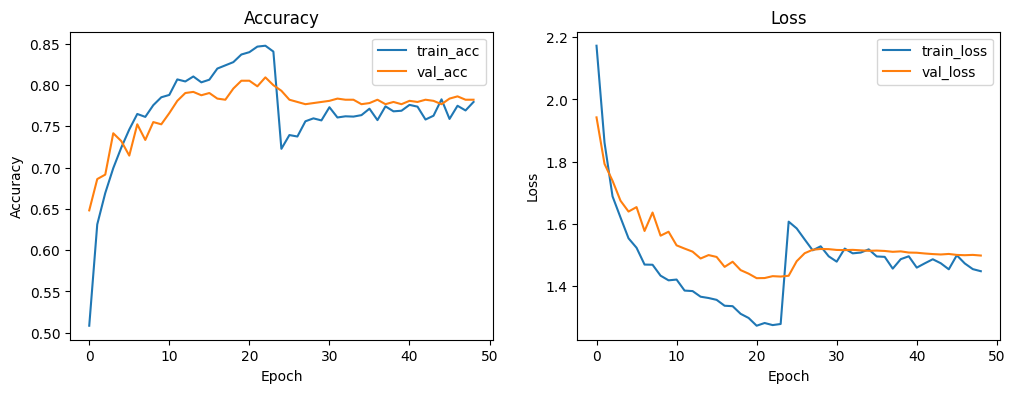

In [ ]:
# 10. Plot training/validation accuracy & loss (uses combined_history)

# Combine histories
def combine_histories(h1, h2):
    combined = {}
    for k in h1.history:
        combined[k] = h1.history[k] + h2.history.get(k, [])
    for k in h2.history:
        if k not in combined:
            combined[k] = h2.history[k]
    return combined

combined_history = combine_histories(history_head, history_fine)

acc = combined_history['accuracy']
val_acc = combined_history['val_accuracy']
loss = combined_history['loss']
val_loss = combined_history['val_loss']

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(acc, label='train_acc')
plt.plot(val_acc, label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss, label='train_loss')
plt.plot(val_loss, label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 676ms/step


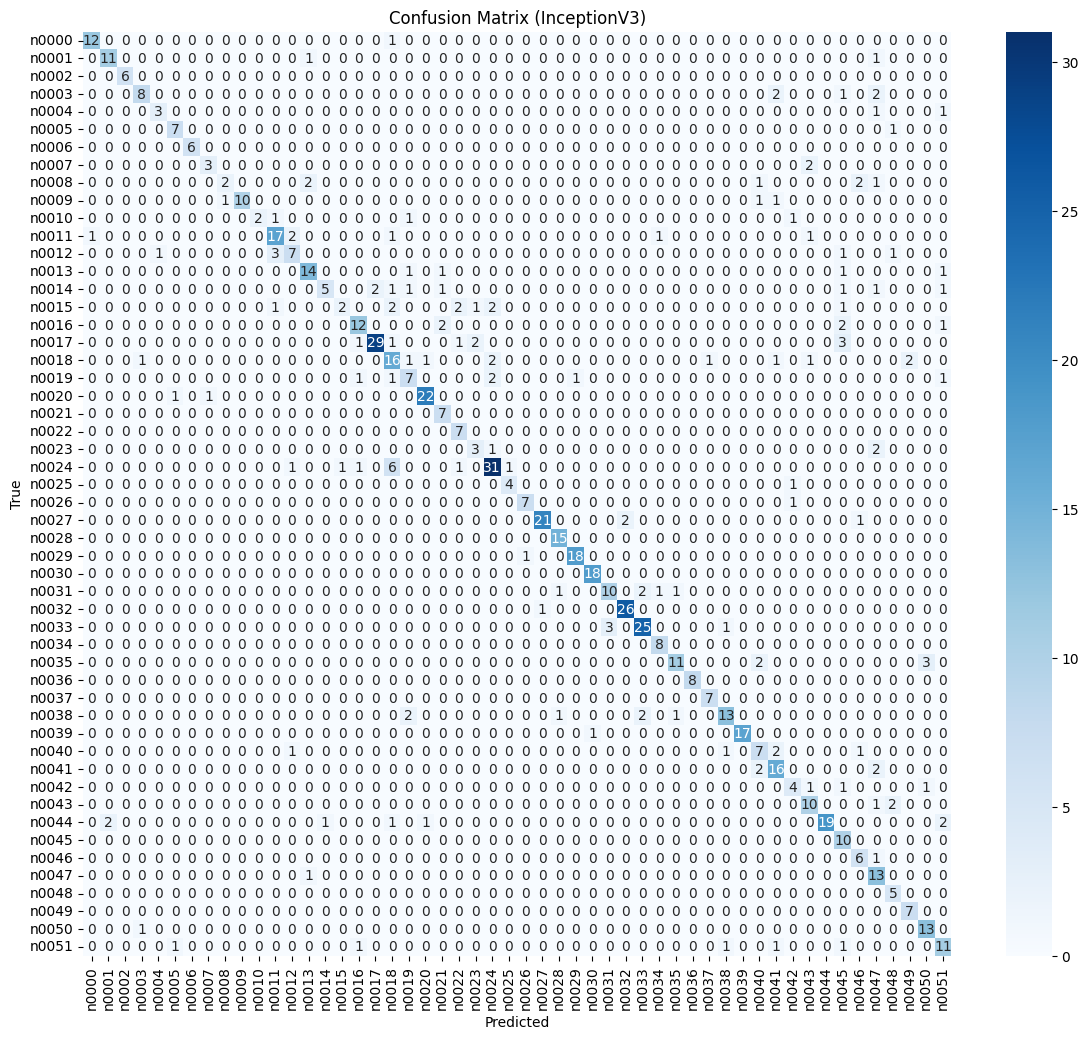

Classification report:

              precision    recall  f1-score   support

       n0000     0.9231    0.9231    0.9231        13
       n0001     0.8462    0.8462    0.8462        13
       n0002     1.0000    1.0000    1.0000         6
       n0003     0.8000    0.6154    0.6957        13
       n0004     0.7500    0.6000    0.6667         5
       n0005     0.7778    0.8750    0.8235         8
       n0006     1.0000    1.0000    1.0000         6
       n0007     0.7500    0.6000    0.6667         5
       n0008     0.6667    0.2500    0.3636         8
       n0009     1.0000    0.7692    0.8696        13
       n0010     1.0000    0.4000    0.5714         5
       n0011     0.7727    0.7391    0.7556        23
       n0012     0.6364    0.5385    0.5833        13
       n0013     0.7778    0.7778    0.7778        18
       n0014     0.8333    0.3846    0.5263        13
       n0015     0.6667    0.1818    0.2857        11
       n0016     0.7500    0.7059    0.7273        17
   

In [ ]:
# 11. Predictions for confusion matrix and classification report

# Predictions
y_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_gen.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (InceptionV3)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Classification report
print("Classification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


# Predict Single image

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.inception_v3 import preprocess_input

def predict_single(img_path, model, IMG_SIZE, class_labels, top_k=3):
    # 1️⃣ Load and preprocess image
    img = image.load_img(img_path, target_size=IMG_SIZE)
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)   # 👈 IMPORTANT: use InceptionV3 preprocessing

    # 2️⃣ Predict probabilities
    probs = model.predict(arr, verbose=0)[0]

    # 3️⃣ Get top-k predicted indices
    top_idx = probs.argsort()[-top_k:][::-1]

    # 4️⃣ Print top predictions
    print("\n🔮 Top Predictions:")
    for i in top_idx:
        print(f"{class_labels[i]:25s} : {probs[i]*100:.2f}%")

    # 5️⃣ Display the image with top prediction in title
    plt.imshow(image.load_img(img_path))
    plt.axis('off')
    plt.title(f"Top-1: {class_labels[top_idx[0]]} ({probs[top_idx[0]]*100:.2f}%)")
    plt.show()


In [ ]:
orchid_label_map = {
    "n0000": "0 - Anoectochilus burmanicus rolfe orchid",
    "n0001": "1 - Bulbophyllum auricomum lindl orchid",
    "n0002": "2 - Bulbophyllum dayanum rchb orchid",
    "n0003": "3 - Bulbophyllum lasiochilum par. & rchb orchid",
    "n0004": "4 - Bulbophyllum limbatum orchid",
    "n0005": "5 - Bulbophyllum longissimum (ridl.) ridl orchid",
    "n0006": "6 - Bulbophyllum medusae (lindl.) rchb orchid",
    "n0007": "7 - Bulbophyllum patens king ex hk.f. orchid",
    "n0008": "8 - Bulbophyllum rufuslabram orchid",
    "n0009": "9 - Bulbophyllum siamensis rchb orchid",
    "n0010": "10 - Calenthe rubens orchid",
    "n0011": "11 - Chiloschista parishii seidenf. orchid",
    "n0012": "12 - Chiloschista viridiflora seidenf. orchid",
    "n0013": "13 - Cymbidium aloifolium (l.) sw. orchid",
    "n0014": "14 - Dendrobium chrysotoxum lindl orchid",
    "n0015": "15 - Dendrobium farmeri paxt. orchid",
    "n0016": "16 - Dendrobium fimbriatum hook orchid",
    "n0017": "17 - Dendrobium lindleyi steud orchid",
    "n0018": "18 - Dendrobium pulchellum roxb orchid",
    "n0019": "19 - Dendrobium pulchellum orchid",
    "n0020": "20 - Dendrobium secundum bl-lindl orchid",
    "n0021": "21 - Dendrobium senile par. & rchb.f. orchid",
    "n0022": "22 - Dendrobium signatum rchb. f orchid",
    "n0023": "23 - Dendrobium thyrsiflorum rchb. f. orchid",
    "n0024": "24 - Dendrobium tortile lindl orchid",
    "n0025": "25 - Dendrobium tortile orchid",
    "n0026": "26 - Hygrochillus parishii var. marrioftiana (rchb.f.) orchid",
    "n0027": "27 - Paphiopedilum bellatulum orchid",
    "n0028": "28 - Paphiopedilum callosum orchid",
    "n0029": "29 - Paphiopedilum charlesworthii orchid",
    "n0030": "30 - Paphiopedilum concolor orchid",
    "n0031": "31 - Paphiopedilum exul orchid",
    "n0032": "32 - Paphiopedilum godefroyae orchid",
    "n0033": "33 - Paphiopedilum gratrixianum orchid",
    "n0034": "34 - Paphiopedilum henryanum orchid",
    "n0035": "35 - Paphiopedilum intanon-villosum orchid",
    "n0036": "36 - Paphiopedilum niveum (rchb.f.) stein orchid",
    "n0037": "37 - Paphiopedilum parishii orchid",
    "n0038": "38 - Paphiopedilum spicerianum orchid",
    "n0039": "39 - Paphiopedilum sukhakulii orchid",
    "n0040": "40 - Pelatantheria bicuspidata (rolfe ex downie) tang & wang orchid",
    "n0041": "41 - Pelatantheria insectiflora (rchb.f.) ridl. orchid",
    "n0042": "42 - Phaius tankervilleae (banks ex i' heritier) blume orchid",
    "n0043": "43 - Phalaenopsis cornucervi (breda) bl. & rchb.f. orchid",
    "n0044": "44 - Rhynchostylis gigantea (lindl.) ridl. orchid",
    "n0045": "45 - Trichoglottis orchideae (koern) garay. orchid",
    "n0046": "46 - Bulbophyllum auratum Lindl. orchid",
    "n0047": "47 - Bulbophyllum morphologorum F.Kranzl. orchid",
    "n0048": "48 - Dendrobium cumulatum Lindl. orchid",
    "n0049": "49 - Maxiralia tenui folia orchid",
    "n0050": "50 - Paphiopedilum vejvarutianum O. Gruss & Roellke orchid",
    "n0051": "51 - Oncidium goldiana orchid"
}


In [ ]:
# Rebuild mapping properly
index_to_folder = {v: k for k, v in train_gen.class_indices.items()}
class_names = [orchid_label_map.get(index_to_folder[i], index_to_folder[i]) for i in range(len(index_to_folder))]

print("\n Class mapping fixed! Example mapping:")
for i in range(5):
    print(f"{i}: {class_names[i]}")



 Class mapping fixed! Example mapping:
0: 0 - Anoectochilus burmanicus rolfe orchid
1: 1 - Bulbophyllum auricomum lindl orchid
2: 2 - Bulbophyllum dayanum rchb orchid
3: 3 - Bulbophyllum lasiochilum par. & rchb orchid
4: 4 - Bulbophyllum limbatum orchid



🔮 Top Predictions:
23 - Dendrobium thyrsiflorum rchb. f. orchid : 90.26%
14 - Dendrobium chrysotoxum lindl orchid : 1.69%
17 - Dendrobium lindleyi steud orchid : 1.41%


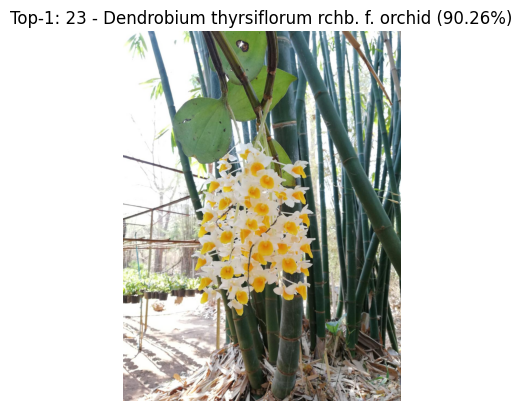

In [ ]:
img_path = "/content/drive/MyDrive/Data set/Flowers Test/n0023/orchid-0013-α╕íα╕¡α╕Öα╣äα╕éα╣ê_13.JPEG"

predict_single(img_path, model, IMG_SIZE, class_names, top_k=3)


🔮 Top Predictions:
23 - Dendrobium thyrsiflorum rchb. f. orchid : 90.26%
14 - Dendrobium chrysotoxum lindl orchid : 1.69%
17 - Dendrobium lindleyi steud orchid : 1.41%


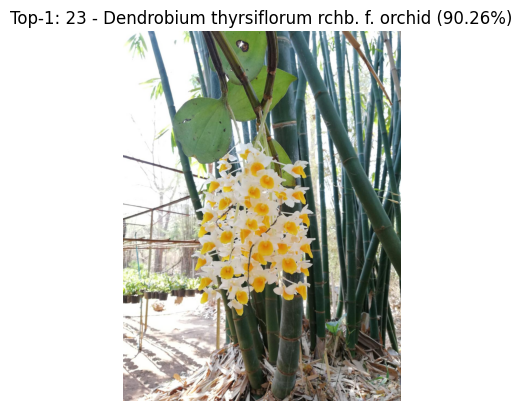

In [ ]:
img_path = "/content/drive/MyDrive/Data set/Flowers Test/n0023/orchid-0013-α╕íα╕¡α╕Öα╣äα╕éα╣ê_13.JPEG"

predict_single(img_path, model, IMG_SIZE, class_names, top_k=3)


🔮 Top Predictions:
50 - Paphiopedilum vejvarutianum O. Gruss & Roellke orchid : 99.64%
35 - Paphiopedilum intanon-villosum orchid : 0.18%
43 - Phalaenopsis cornucervi (breda) bl. & rchb.f. orchid : 0.02%


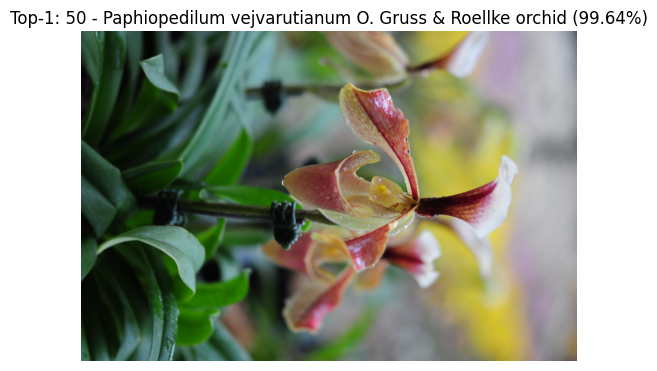

In [ ]:
img_path = "/content/drive/MyDrive/Data set/Flowers Test/n0050/V_Paphiopedilum-vejvarutianum-O-Gruss-Roellke-α╕úα╕¡α╕çα╣Çα╕ùα╣ëα╕▓α╕Öα╕▓α╕úα╕╡α╕öα╕¡α╕óα╕òα╕╕α╕çα╕üα╕▓α╕ìα╕êα╕Öα╣î_4.JPG"

predict_single(img_path, model, IMG_SIZE, class_names, top_k=3)


🔮 Top Predictions:
16 - Dendrobium fimbriatum hook orchid : 30.92%
51 - Oncidium goldiana orchid : 18.93%
1 - Bulbophyllum auricomum lindl orchid : 6.72%


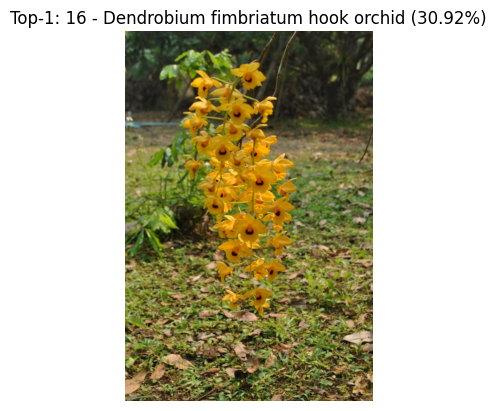

In [ ]:
img_path = "/content/drive/MyDrive/Data set/Flowers Test/n0016/orchid-0010-α╣üα╕ºα╕ºα╕íα╕óα╕╕α╕úα╕▓_52.JPEG"

predict_single(img_path, model, IMG_SIZE, class_names, top_k=3)

# Save the Model

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Save to Google Drive
SAVE_PATH = "/content/drive/MyDrive/Model/inception_orchid_final.h5"  # change path if needed
model.save(SAVE_PATH)
print(f" Model saved to: {SAVE_PATH}")

 Model saved to: /content/drive/MyDrive/Model/inception_orchid_final.h5


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.inception_v3 import preprocess_input
import tensorflow as tf

# Load the model
model = load_model("/content/drive/MyDrive/Model/inception_orchid_final.h5", compile=False)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
print(" Model loaded successfully and ready for inference!")

 Model loaded successfully and ready for inference!
